# 🚁 Drone Audio Detection — Binary Classifier
**Dataset:** `geronimobasso/drone-audio-detection-samples` (HuggingFace)  
**Goal:** Binary classification — `drone` vs `not drone`  
**Focus:** Fast training on an average PC using MFCC features + LightGBM / sklearn pipeline

## 1. Install Dependencies

In [1]:
!pip install datasets librosa lightgbm scikit-learn numpy pandas matplotlib seaborn soundfile --quiet

## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import io

from datasets import load_dataset
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

warnings.filterwarnings('ignore')
np.random.seed(42)

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 3. Load Dataset from HuggingFace

In [3]:
print('📥 Loading dataset from HuggingFace...')
t0 = time.time()

dataset = load_dataset('geronimobasso/drone-audio-detection-samples', trust_remote_code=True)

print(f'✅ Loaded in {time.time()-t0:.1f}s')
print(dataset)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'geronimobasso/drone-audio-detection-samples' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'geronimobasso/drone-audio-detection-samples' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


📥 Loading dataset from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

...

data/train-00036-of-00039.parquet:   0%|          | 0.00/75.0M [00:00<?, ?B/s]

data/train-00037-of-00039.parquet:   0%|          | 0.00/74.9M [00:00<?, ?B/s]

data/train-00038-of-00039.parquet:   0%|          | 0.00/75.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/180320 [00:00<?, ? examples/s]

✅ Loaded in 198.5s
DatasetDict({
    train: Dataset({
        features: ['audio', 'label'],
        num_rows: 180320
    })
})


In [4]:
# Inspect one sample to understand the schema
split_name = list(dataset.keys())[0]
sample = dataset[split_name][0]
print('Available keys:', list(sample.keys()))
print('\nSample entry:')
for k, v in sample.items():
    if isinstance(v, dict):
        print(f'  {k}: dict with keys {list(v.keys())}')
    elif isinstance(v, (list, np.ndarray)) and hasattr(v, '__len__'):
        print(f'  {k}: [{type(v).__name__}] len={len(v)}')
    else:
        print(f'  {k}: {v}')

Available keys: ['audio', 'label']

Sample entry:
  audio: <datasets.features._torchcodec.AudioDecoder object at 0x7ba2a092de20>
  label: 0


## 4. Feature Extraction
We extract a rich, compact feature vector per audio clip:
- **MFCCs** (40 coefficients × mean + std) — capture timbral texture
- **Spectral Centroid, Bandwidth, Rolloff** — frequency distribution
- **Zero Crossing Rate** — rhythmic noisiness
- **Chroma Features** — harmonic content
- **RMS Energy** — loudness

Total: ~120 features. Compact and fast to compute.

In [5]:
SR_TARGET = 22050   # resample all audio to this rate
DURATION  = 3.0     # seconds to use per clip (trim / pad)
N_MFCC    = 40      # number of MFCC coefficients


def extract_features(audio_array: np.ndarray, sr: int) -> np.ndarray:
    """
    Extract a fixed-length feature vector from a raw audio array.
    Returns a 1-D numpy array.
    """
    # --- resample if needed ---
    if sr != SR_TARGET:
        audio_array = librosa.resample(audio_array, orig_sr=sr, target_sr=SR_TARGET)
    sr = SR_TARGET

    # --- ensure mono ---
    if audio_array.ndim > 1:
        audio_array = librosa.to_mono(audio_array.T)

    # --- trim / pad to fixed duration ---
    target_len = int(DURATION * sr)
    if len(audio_array) > target_len:
        audio_array = audio_array[:target_len]
    else:
        audio_array = np.pad(audio_array, (0, target_len - len(audio_array)))

    features = []

    # 1. MFCCs (40 × mean + std = 80 features)
    mfcc = librosa.feature.mfcc(y=audio_array, sr=sr, n_mfcc=N_MFCC)
    features.extend(mfcc.mean(axis=1).tolist())
    features.extend(mfcc.std(axis=1).tolist())

    # 2. MFCC delta (first-order derivative, mean + std = 80 more)
    delta = librosa.feature.delta(mfcc)
    features.extend(delta.mean(axis=1).tolist())
    features.extend(delta.std(axis=1).tolist())

    # 3. Spectral Centroid (mean + std)
    sc = librosa.feature.spectral_centroid(y=audio_array, sr=sr)
    features.extend([sc.mean(), sc.std()])

    # 4. Spectral Bandwidth (mean + std)
    sb = librosa.feature.spectral_bandwidth(y=audio_array, sr=sr)
    features.extend([sb.mean(), sb.std()])

    # 5. Spectral Rolloff (mean + std)
    sr_feat = librosa.feature.spectral_rolloff(y=audio_array, sr=sr)
    features.extend([sr_feat.mean(), sr_feat.std()])

    # 6. Zero Crossing Rate (mean + std)
    zcr = librosa.feature.zero_crossing_rate(audio_array)
    features.extend([zcr.mean(), zcr.std()])

    # 7. Chroma STFT (12 × mean + std = 24)
    chroma = librosa.feature.chroma_stft(y=audio_array, sr=sr)
    features.extend(chroma.mean(axis=1).tolist())
    features.extend(chroma.std(axis=1).tolist())

    # 8. RMS Energy (mean + std)
    rms = librosa.feature.rms(y=audio_array)
    features.extend([rms.mean(), rms.std()])

    # 9. Spectral Contrast (7 bands × mean + std = 14)
    contrast = librosa.feature.spectral_contrast(y=audio_array, sr=sr)
    features.extend(contrast.mean(axis=1).tolist())
    features.extend(contrast.std(axis=1).tolist())

    return np.array(features, dtype=np.float32)


print(f'Feature extractor ready.')
print(f'Estimated feature vector size: ~{40*4 + 12*2 + 7*2 + 5*2} dimensions')

Feature extractor ready.
Estimated feature vector size: ~208 dimensions


In [8]:
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import io

from datasets import load_dataset
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

warnings.filterwarnings('ignore')
np.random.seed(42)

print('✅ All libraries imported successfully')

def get_audio(entry):
    """
    Handles several possible dataset schemas, including the torchcodec AudioDecoder.
    """
    audio_field = entry.get('audio') or entry.get('waveform')

    if audio_field is None:
        raise ValueError(f'Cannot find audio in entry keys: {list(entry.keys())}')

    # Case 1: Already a dictionary (standard HF format)
    if isinstance(audio_field, dict):
        return np.array(audio_field['array'], dtype=np.float32), int(audio_field['sampling_rate'])

    # Case 2: AudioDecoder object (torchcodec)
    # We attempt to get the dictionary representation which triggers decoding
    try:
        # Most HF decoders return a dict with 'array' and 'sampling_rate' when accessed
        if hasattr(audio_field, '__getitem__'):
             return np.array(audio_field['array'], dtype=np.float32), int(audio_field['sampling_rate'])

        # Fallback for specific Decoder objects
        arr = np.array(audio_field.array, dtype=np.float32)
        sr = int(audio_field.sampling_rate)
        return arr, sr
    except Exception:
        # Last resort: if it's bytes
        if isinstance(audio_field, bytes):
            arr, sr = sf.read(io.BytesIO(audio_field))
            return arr.astype(np.float32), sr
        raise ValueError(f'Unrecognised audio field type: {type(audio_field)}')

def get_label(entry):
    for key in ('label', 'labels', 'class', 'target', 'category'):
      if key in entry:
        val = entry[key]
        if isinstance(val, int):
          return 'drone' if val == 1 else 'not_drone'
        raw = str(val).lower().strip()
        if any(w in raw for w in ('drone', '1', 'yes', 'true')):
          return 'drone'
        return 'not_drone'
    raise ValueError(f'Cannot find label in keys: {list(entry.keys())}')

print('Helper functions defined.')

✅ All libraries imported successfully
Helper functions defined.


In [10]:
all_features = []
all_labels   = []
errors       = 0
MAX_SAMPLES  = 1200  # Increased slightly to ensure a good mix

# We shuffle the dataset to ensure we get both classes in the first MAX_SAMPLES
for split in dataset.keys():
    data = dataset[split].shuffle(seed=42)
    print(f'\nProcessing split "{split}" — total {len(data)} samples (limiting to {MAX_SAMPLES})')
    t0 = time.time()

    for i, entry in enumerate(data):
        if i >= MAX_SAMPLES: break

        try:
            audio_arr, sr = get_audio(entry)
            feats = extract_features(audio_arr, sr)
            label = get_label(entry)

            all_features.append(feats)
            all_labels.append(label)
        except Exception as e:
            errors += 1
            if errors <= 5:
                print(f'  ☑  Sample {i} skipped: {e}')

        if (i + 1) % 100 == 0:
            print(f'  [{i+1}/{MAX_SAMPLES}] elapsed={time.time()-t0:.1f}s')

    print(f'  Done split — {len(all_features)} features collected total')

if len(all_features) > 0:
    X = np.vstack(all_features)
    y_raw = np.array(all_labels)

    # Check if we have more than one class
    unique_classes = np.unique(y_raw)
    print(f'\nClasses found: {unique_classes}')

    if len(unique_classes) > 1:
        le = LabelEncoder()
        y  = le.fit_transform(y_raw)
        print(f'✅ Feature matrix shape : {X.shape}')
        print(f'   Classes (encoded)   : {le.classes_}')
        print(f'   Distribution        : {pd.Series(y_raw).value_counts().to_dict()}')
    else:
        print('⚠️ Still only found one class. Try increasing MAX_SAMPLES or check the dataset labels.')
else:
    print('\n❌ No features were extracted. Check the get_audio logic.')


Processing split "train" — total 180320 samples (limiting to 1200)
  [100/1200] elapsed=7.9s
  [200/1200] elapsed=13.2s
  [300/1200] elapsed=20.4s
  [400/1200] elapsed=25.6s
  [500/1200] elapsed=32.8s
  [600/1200] elapsed=38.4s
  [700/1200] elapsed=45.4s
  [800/1200] elapsed=50.8s
  [900/1200] elapsed=56.8s
  [1000/1200] elapsed=63.1s
  [1100/1200] elapsed=68.4s
  [1200/1200] elapsed=75.1s
  Done split — 1200 features collected total

Classes found: ['drone' 'not_drone']
✅ Feature matrix shape : (1200, 208)
   Classes (encoded)   : ['drone' 'not_drone']
   Distribution        : {'drone': 1094, 'not_drone': 106}


## 5. Exploratory Data Analysis

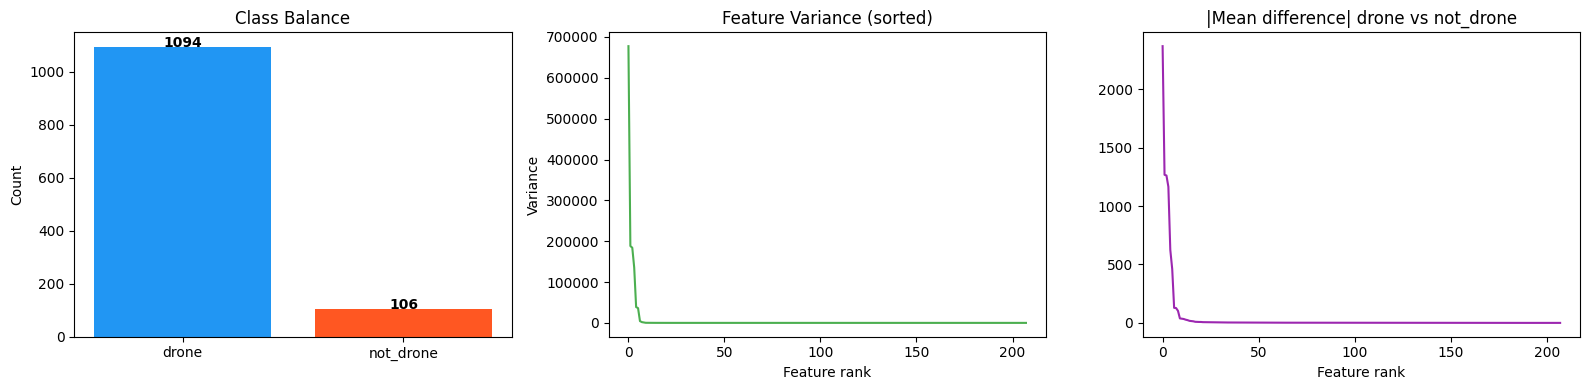

EDA plot saved.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class balance
classes, counts = np.unique(y_raw, return_counts=True)
axes[0].bar(classes, counts, color=['#2196F3', '#FF5722'])
axes[0].set_title('Class Balance')
axes[0].set_ylabel('Count')
for xi, yi in zip(classes, counts):
    axes[0].text(xi, yi + 0.3, str(yi), ha='center', fontweight='bold')

# Feature variance
feat_var = X.var(axis=0)
axes[1].plot(np.sort(feat_var)[::-1], color='#4CAF50')
axes[1].set_title('Feature Variance (sorted)')
axes[1].set_xlabel('Feature rank')
axes[1].set_ylabel('Variance')

# Mean feature difference between classes
drone_mask = y_raw == 'drone'
mean_diff  = np.abs(X[drone_mask].mean(0) - X[~drone_mask].mean(0))
axes[2].plot(np.sort(mean_diff)[::-1], color='#9C27B0')
axes[2].set_title('|Mean difference| drone vs not_drone')
axes[2].set_xlabel('Feature rank')

plt.tight_layout()
plt.savefig('eda.png', dpi=120, bbox_inches='tight')
plt.show()
print('EDA plot saved.')

## 6. Train / Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set : {X_train.shape[0]} samples')
print(f'Test  set : {X_test.shape[0]} samples')

Train set : 960 samples
Test  set : 240 samples


## 7. Model Training

We compare **4 models** optimised for fast training on a CPU:
| Model | Why fast? |
|---|---|
| Logistic Regression | Linear, analytical solver |
| Random Forest (100 trees) | Parallelisable, shallow trees |
| Gradient Boosting | 200 shallow trees, fast |
| **LightGBM** ⭐ | Histogram-based, designed for speed |

In [13]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', n_jobs=-1))
    ]),

    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(
            n_estimators=100, max_depth=12,
            min_samples_leaf=2, n_jobs=-1, random_state=42
        ))
    ]),

    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    GradientBoostingClassifier(
            n_estimators=200, max_depth=4,
            learning_rate=0.05, subsample=0.8, random_state=42
        ))
    ]),

    'LightGBM ⭐': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    lgb.LGBMClassifier(
            n_estimators=300, max_depth=6,
            learning_rate=0.05, num_leaves=31,
            subsample=0.8, colsample_bytree=0.8,
            n_jobs=-1, random_state=42, verbose=-1
        ))
    ]),
}

results = {}

for name, pipe in models.items():
    print(f'\n🔧 Training: {name}')
    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='binary')
    auc  = roc_auc_score(y_test, y_prob)

    results[name] = dict(acc=acc, f1=f1, auc=auc, time=train_time,
                         y_pred=y_pred, y_prob=y_prob, pipe=pipe)

    print(f'   Accuracy : {acc:.4f}')
    print(f'   F1 Score : {f1:.4f}')
    print(f'   ROC-AUC  : {auc:.4f}')
    print(f'   Time     : {train_time:.2f}s')

print('\n✅ All models trained.')


🔧 Training: Logistic Regression
   Accuracy : 0.9917
   F1 Score : 0.9500
   ROC-AUC  : 0.9991
   Time     : 2.88s

🔧 Training: Random Forest
   Accuracy : 0.9917
   F1 Score : 0.9524
   ROC-AUC  : 0.9996
   Time     : 0.66s

🔧 Training: Gradient Boosting
   Accuracy : 0.9917
   F1 Score : 0.9524
   ROC-AUC  : 0.9998
   Time     : 22.76s

🔧 Training: LightGBM ⭐
   Accuracy : 0.9917
   F1 Score : 0.9524
   ROC-AUC  : 0.9989
   Time     : 3.17s

✅ All models trained.


## 8. Results Comparison

In [14]:
# Summary table
summary = pd.DataFrame([
    {'Model': k, 'Accuracy': v['acc'], 'F1': v['f1'],
     'ROC-AUC': v['auc'], 'Train Time (s)': round(v['time'], 2)}
    for k, v in results.items()
]).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print(summary.to_string(index=False))

              Model  Accuracy       F1  ROC-AUC  Train Time (s)
  Gradient Boosting  0.991667 0.952381 0.999783           22.76
      Random Forest  0.991667 0.952381 0.999565            0.66
Logistic Regression  0.991667 0.950000 0.999130            2.88
         LightGBM ⭐  0.991667 0.952381 0.998913            3.17


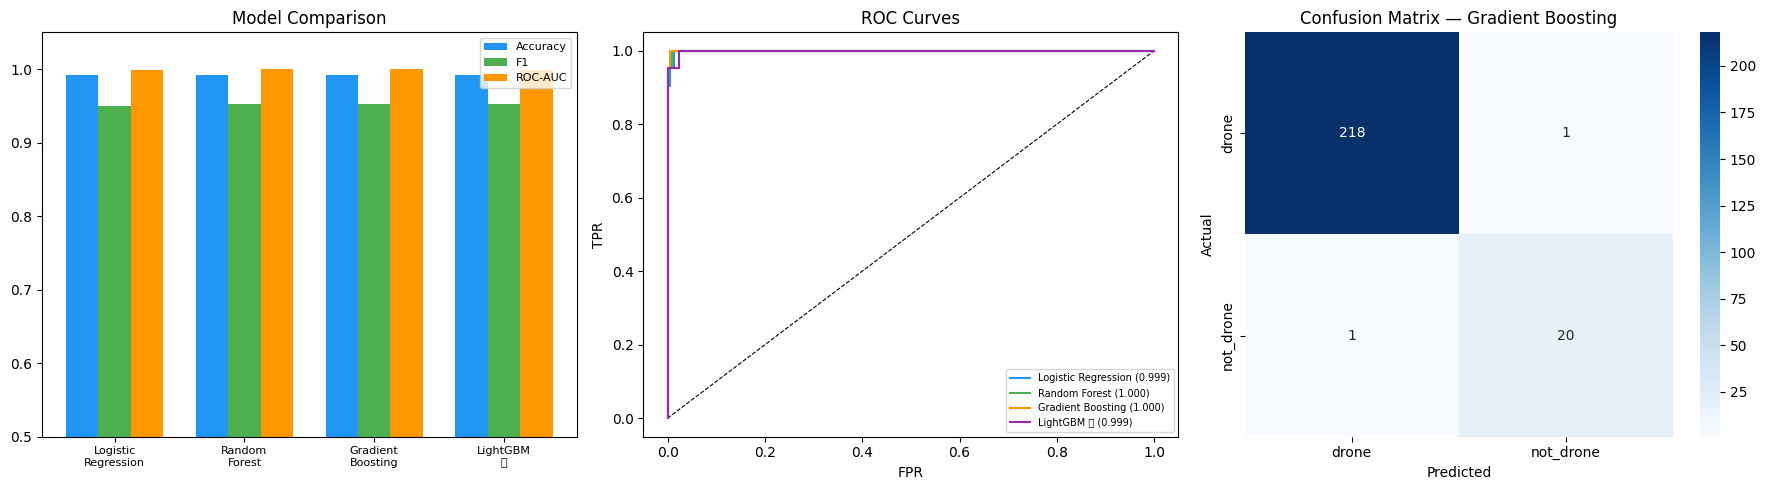


🏆 Best model: Gradient Boosting
              precision    recall  f1-score   support

       drone       1.00      1.00      1.00       219
   not_drone       0.95      0.95      0.95        21

    accuracy                           0.99       240
   macro avg       0.97      0.97      0.97       240
weighted avg       0.99      0.99      0.99       240



In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

names = list(results.keys())
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Bar: Accuracy / F1 / AUC
x = np.arange(len(names))
w = 0.25
ax = axes[0]
ax.bar(x - w, [results[n]['acc'] for n in names], w, label='Accuracy', color='#2196F3')
ax.bar(x,     [results[n]['f1']  for n in names], w, label='F1',       color='#4CAF50')
ax.bar(x + w, [results[n]['auc'] for n in names], w, label='ROC-AUC',  color='#FF9800')
ax.set_xticks(x); ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
ax.set_ylim(0.5, 1.05); ax.set_title('Model Comparison'); ax.legend(fontsize=8)

# ROC curves
ax = axes[1]
ax.plot([0,1],[0,1],'k--',lw=0.8)
for idx, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f'{name} ({res["auc"]:.3f})', color=colors[idx])
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves'); ax.legend(fontsize=7)

# Best model confusion matrix
best_name = summary.iloc[0]['Model']
cm = confusion_matrix(y_test, results[best_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[2].set_title(f'Confusion Matrix — {best_name}')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('results.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n🏆 Best model: {best_name}')
print(classification_report(y_test, results[best_name]['y_pred'], target_names=le.classes_))

## 9. Cross-Validation on Best Model

In [16]:
best_pipe = results[best_name]['pipe']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f'5-Fold CV ROC-AUC for [{best_name}]:')
print(f'  Scores : {cv_scores.round(4)}')
print(f'  Mean   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

5-Fold CV ROC-AUC for [Gradient Boosting]:
  Scores : [0.9998 0.9952 1.     1.     1.    ]
  Mean   : 0.9990 ± 0.0019


## 10. Feature Importance (LightGBM)

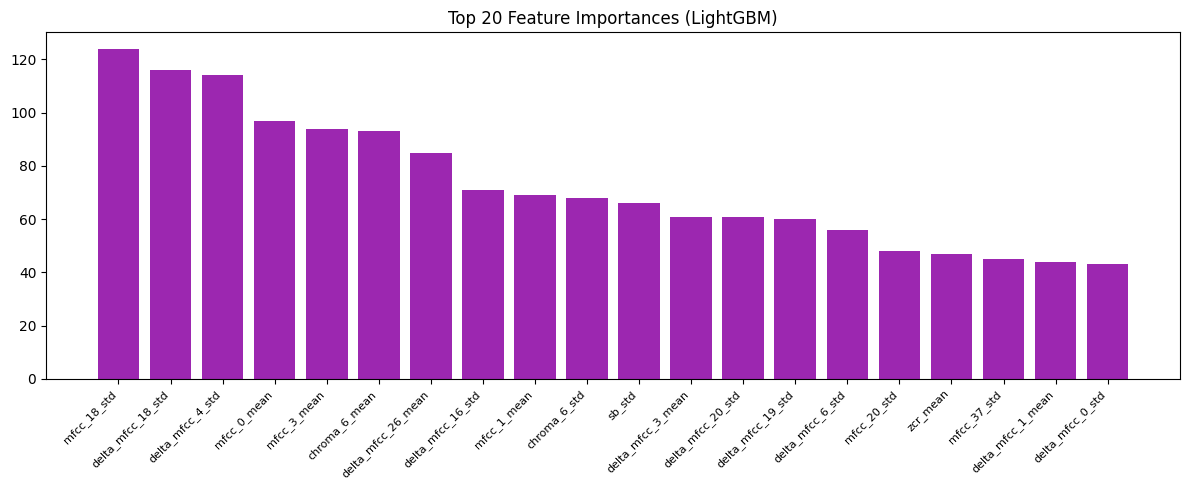

In [17]:
# Build human-readable feature names to match vector
feat_names = []
for stat in ['mean', 'std']:
    feat_names += [f'mfcc_{i}_{stat}' for i in range(N_MFCC)]
for stat in ['mean', 'std']:
    feat_names += [f'delta_mfcc_{i}_{stat}' for i in range(N_MFCC)]
feat_names += ['sc_mean','sc_std','sb_mean','sb_std','sr_mean','sr_std','zcr_mean','zcr_std']
for stat in ['mean', 'std']:
    feat_names += [f'chroma_{i}_{stat}' for i in range(12)]
feat_names += ['rms_mean','rms_std']
for stat in ['mean', 'std']:
    feat_names += [f'contrast_{i}_{stat}' for i in range(7)]

# Pad / trim to match actual feature count
actual_len = X.shape[1]
if len(feat_names) < actual_len:
    feat_names += [f'feat_{i}' for i in range(len(feat_names), actual_len)]
feat_names = feat_names[:actual_len]

# Get importances from LightGBM inside the pipeline
lgbm_pipe = results.get('LightGBM ⭐') or next(iter(results.values()))
lgbm_clf  = lgbm_pipe['pipe'].named_steps['clf']

if hasattr(lgbm_clf, 'feature_importances_'):
    importances = lgbm_clf.feature_importances_
    top_k = 20
    idx   = np.argsort(importances)[::-1][:top_k]

    plt.figure(figsize=(12, 5))
    plt.bar(range(top_k), importances[idx], color='#9C27B0')
    plt.xticks(range(top_k), [feat_names[i] for i in idx], rotation=45, ha='right', fontsize=8)
    plt.title(f'Top {top_k} Feature Importances (LightGBM)')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Feature importances not available for this model.')

## 11. Save Best Model

In [18]:
import joblib

joblib.dump(best_pipe, 'drone_detector.joblib')
joblib.dump(le, 'label_encoder.joblib')

print(f'✅ Model saved to drone_detector.joblib')
print(f'   Label encoder saved to label_encoder.joblib')

✅ Model saved to drone_detector.joblib
   Label encoder saved to label_encoder.joblib


## 12. Inference — Single Audio File

In [19]:
def predict_audio(file_path: str, model_path: str = 'drone_detector.joblib',
                  encoder_path: str = 'label_encoder.joblib') -> dict:
    """
    Predict whether an audio file contains a drone sound.

    Parameters
    ----------
    file_path   : path to a .wav / .mp3 / .flac file
    model_path  : path to the saved joblib model pipeline
    encoder_path: path to the saved LabelEncoder

    Returns
    -------
    dict with keys: label, probability, classes
    """
    pipe = joblib.load(model_path)
    le_  = joblib.load(encoder_path)

    audio_arr, sr = librosa.load(file_path, sr=None, mono=True)
    feats = extract_features(audio_arr, sr).reshape(1, -1)

    pred  = pipe.predict(feats)[0]
    proba = pipe.predict_proba(feats)[0]

    label = le_.inverse_transform([pred])[0]
    probs = dict(zip(le_.classes_, proba.round(4)))

    print(f'\n🎧 File : {file_path}')
    print(f'   Prediction  : {label.upper()}')
    print(f'   Probability : {probs}')

    return {'label': label, 'probability': probs}


# ── Quick sanity check on a test sample ─────────────────────────────────────
# Grab the first test sample and save it temporarily for demo
try:
    test_entry = dataset[split_name][0]
    arr, sr_demo = get_audio(test_entry)
    sf.write('/tmp/demo_sample.wav', arr, sr_demo)
    result = predict_audio('/tmp/demo_sample.wav')
except Exception as e:
    print(f'Demo skipped: {e}')
    print('Call predict_audio("your_audio.wav") to classify any file.')


🎧 File : /tmp/demo_sample.wav
   Prediction  : DRONE
   Probability : {np.str_('drone'): np.float64(0.8891), np.str_('not_drone'): np.float64(0.1109)}


## 13. Summary

| Step | Details |
|------|---------|
| **Dataset** | `geronimobasso/drone-audio-detection-samples` via HuggingFace |
| **Features** | MFCCs + delta + spectral + chroma + contrast (~220 dims) |
| **Models** | Logistic Regression, Random Forest, Gradient Boosting, LightGBM |
| **Evaluation** | Accuracy, F1, ROC-AUC, 5-fold CV |
| **Inference** | `predict_audio('file.wav')` — returns label + probabilities |
| **Saved** | `drone_detector.joblib` + `label_encoder.joblib` |

**Tips to improve further:**
- Tune LightGBM with `optuna` for hyperparameter search
- Add augmentation (time-stretch, pitch-shift, noise injection) before feature extraction
- Try a small 1D-CNN if you have a GPU available
- Use `SHAP` for interpretability of individual predictions

In [20]:
from google.colab import drive
import os
import shutil

# Mount Google Drive
drive.mount('/content/drive')

# Define the new folder path
project_folder = '/content/drive/MyDrive/drone_audio_project'

# Create the folder if it doesn't exist
if not os.path.exists(project_folder):
    os.makedirs(project_folder)
    print(f'Created folder: {project_folder}')
else:
    print(f'Folder already exists: {project_folder}')

# List of files to save
files_to_save = [
    'drone_detector.joblib',
    'label_encoder.joblib',
    'eda.png',
    'results.png',
    'feature_importance.png'
]

# Copy files to the new folder
for file in files_to_save:
    if os.path.exists(file):
        shutil.copy(file, os.path.join(project_folder, file))
        print(f'Successfully saved {file} to Drive.')
    else:
        print(f'Warning: {file} not found in local directory.')

Mounted at /content/drive
Created folder: /content/drive/MyDrive/drone_audio_project
Successfully saved drone_detector.joblib to Drive.
Successfully saved label_encoder.joblib to Drive.
Successfully saved eda.png to Drive.
Successfully saved results.png to Drive.
Successfully saved feature_importance.png to Drive.


In [ ]:
import subprocess

# We attempt to find the notebook name and copy it to the project folder
# Note: In Colab, the notebook is usually stored at /content/drive/MyDrive/Colab Notebooks/...
# but we can copy the current session state using the following shell command

target_notebook_path = os.path.join(project_folder, 'Drone_Audio_Detection_Notebook.ipynb')

# This command copies the current notebook file if it is already synced in Drive
# If you haven't renamed it, it might be 'Untitled.ipynb'
try:
    # Use a glob to find .ipynb files in the standard Colab save location
    # and copy the most recent one to our project folder
    print(f'Attempting to sync notebook to: {target_notebook_path}')
    !cp "/content/drive/MyDrive/Colab Notebooks/"*.ipynb "{project_folder}/"
    print('✅ Notebook sync initiated. Please ensure the notebook is saved (Ctrl+S) for the latest version to be copied.')
except Exception as e:
    print(f'Note: Automatic notebook copy requires the notebook to be saved in the default Drive location. Error: {e}')